# Channel Signal Distributions

This notebook visualizes the per-channel (singlet, triplet, IR, quasiparticle/evaporation) signal distributions produced by `simulate_spectrum.py`.

**Sections:**
1. Theoretical yield curves (no simulation data needed)
2. Per-channel detected energy vs. recoil energy
3. Channel composition (stacked fractions)
4. Arrival time distributions
5. Spectrum-specific plots (WIMP masses, flat spectra, etc.)

In [38]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import HeST as H

## -------------------------------- ##
##        SET PLOTTING STYLE        ##
## -------------------------------- ##
matplotlib.rcParams['figure.figsize'] = 8.5,6
matplotlib.rcParams['figure.subplot.left'] = 0.15
matplotlib.rcParams['figure.subplot.right'] = 0.88
matplotlib.rcParams['figure.subplot.bottom'] = 0.15
matplotlib.rcParams['figure.subplot.top'] = 0.88
matplotlib.rcParams['axes.titlesize'] = 20
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.labelweight'] = 'normal'
matplotlib.rcParams['font.weight'] = 'normal' 
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['lines.linewidth'] = 2
matplotlib.rcParams['lines.markersize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 16
matplotlib.rcParams['ytick.labelsize'] = 16
matplotlib.rcParams['xtick.major.size'] = 8
matplotlib.rcParams['ytick.major.size'] = 8
matplotlib.rcParams['xtick.minor.size'] = 4
matplotlib.rcParams['ytick.minor.size'] = 4
matplotlib.rcParams['xtick.minor.visible'] = True 
matplotlib.rcParams['ytick.minor.visible'] = True
matplotlib.rcParams['xtick.direction'] = 'in' 
matplotlib.rcParams['ytick.direction'] = 'in' 
matplotlib.rcParams['xtick.top'] = True 
matplotlib.rcParams['ytick.right'] = True
matplotlib.rcParams['xtick.major.pad'] = 6
matplotlib.rcParams['image.cmap'] = 'viridis'

CHANNEL_NAMES = ['Singlet', 'Triplet', 'IR', 'QP/Evaporation']
CHANNEL_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

In [119]:
# Load simulation results — set this to the .npz file produced by simulate_spectrum.py
DATA_FILE = 'Sims/Spectrum_Flat_ER_energyMin_10_energyMax_1000_nEvents_10000_Heraldv1.npz'

data = np.load(DATA_FILE, allow_pickle=True)

print(list(data.keys()))

recoil_energies = data['recoil_energies']
recoil_types = data['recoil_types']  # 0 = ER, 1 = NR
n_quanta_generated = data['n_quanta_generated']  # (n_events, 4)
detected_energy = data['detected_energy']  # (n_events, 4)
detected_count = data['detected_count']  # (n_events, 4)
mean_arrival_time = data['mean_arrival_time']  # (n_events, 4)
spectrum_mode = str(data['spectrum_mode'])
detector_config = data['detector_config'].item()

has_wimp = 'wimp_mass' in data
if has_wimp:
    wimp_mass = float(data['wimp_mass'])

er_mask = recoil_types == 0
nr_mask = recoil_types == 1

print(f'Spectrum mode: {spectrum_mode}')
print(f'Recoil type: {"ER" if er_mask.any() else "NR"}')
print(f'Total events: {len(recoil_energies)}')
if has_wimp:
    print(f'WIMP mass: {wimp_mass} MeV')
print(f'Detector: {detector_config}')

['recoil_energies', 'recoil_types', 'n_quanta_generated', 'detected_energy', 'detected_count', 'mean_arrival_time', 'spectrum_mode', 'detector_config', 'sensor_det_energy', 'sensor_det_count', 'sensor_det_time']
Spectrum mode: flat
Recoil type: ER
Total events: 10000
Detector: {'detector_geometry': 'HeRALD_v1', 'fill_height': 4.5, 'cell_radius': 3.5, 'qp_wall_reflection_prob': 0.3, 'qp_wall_diffuse_prob': 0.0, 'qp_sensor_reflection_prob': 0.0, 'uv_wall_reflection_prob': 0.3, 'uv_wall_diffuse_prob': 0.0, 'ir_wall_reflection_prob': 0.0, 'ir_wall_diffuse_prob': 0.0, 'step_size': 0.05, 'max_dist': 10.0, 'qp_temperature': 2.0, 'max_qp_simulated': 100000}


# Theoretical Yield Curves

These plots use the analytic yield functions directly — no simulation data needed.

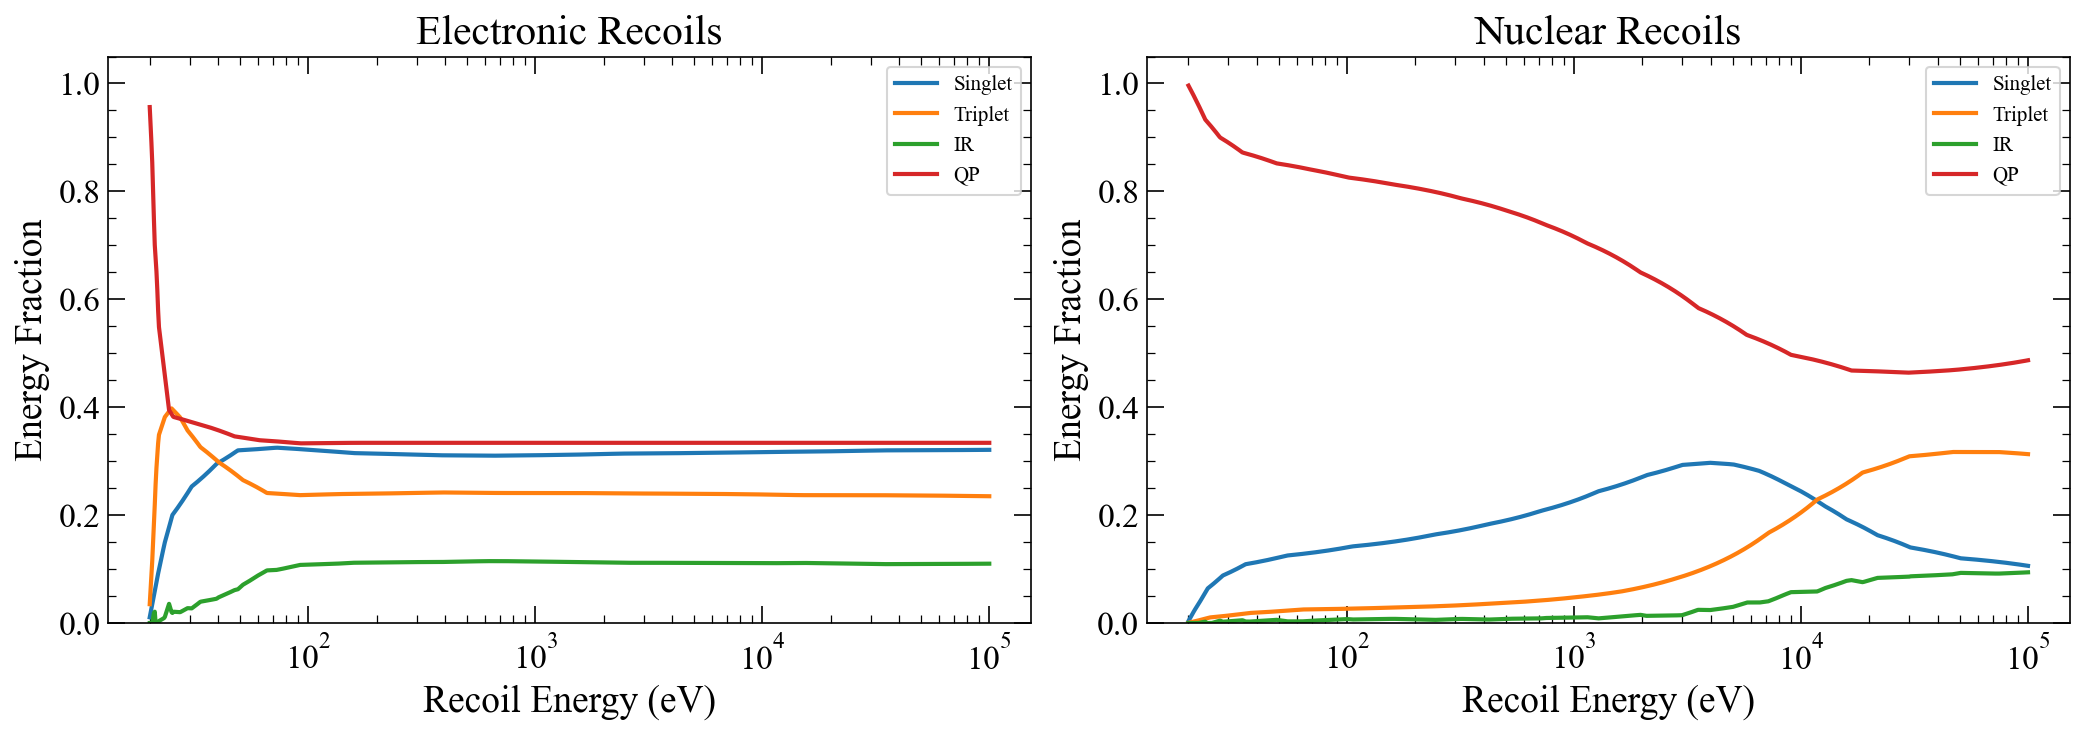

In [39]:
E_theory = np.geomspace(20, 100000, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, interaction, title in zip(axes, ['ER', 'NR'],
                                   ['Electronic Recoils', 'Nuclear Recoils']):
    s, t, qp, ir = H.GetEnergyChannelFractions(E_theory, interaction)
    ax.plot(E_theory, s, color=CHANNEL_COLORS[0], label='Singlet')
    ax.plot(E_theory, t, color=CHANNEL_COLORS[1], label='Triplet')
    ax.plot(E_theory, ir, color=CHANNEL_COLORS[2], label='IR')
    ax.plot(E_theory, qp, color=CHANNEL_COLORS[3], label='QP')
    ax.set_xscale('log')
    ax.set_xlabel('Recoil Energy (eV)')
    ax.set_ylabel('Energy Fraction')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

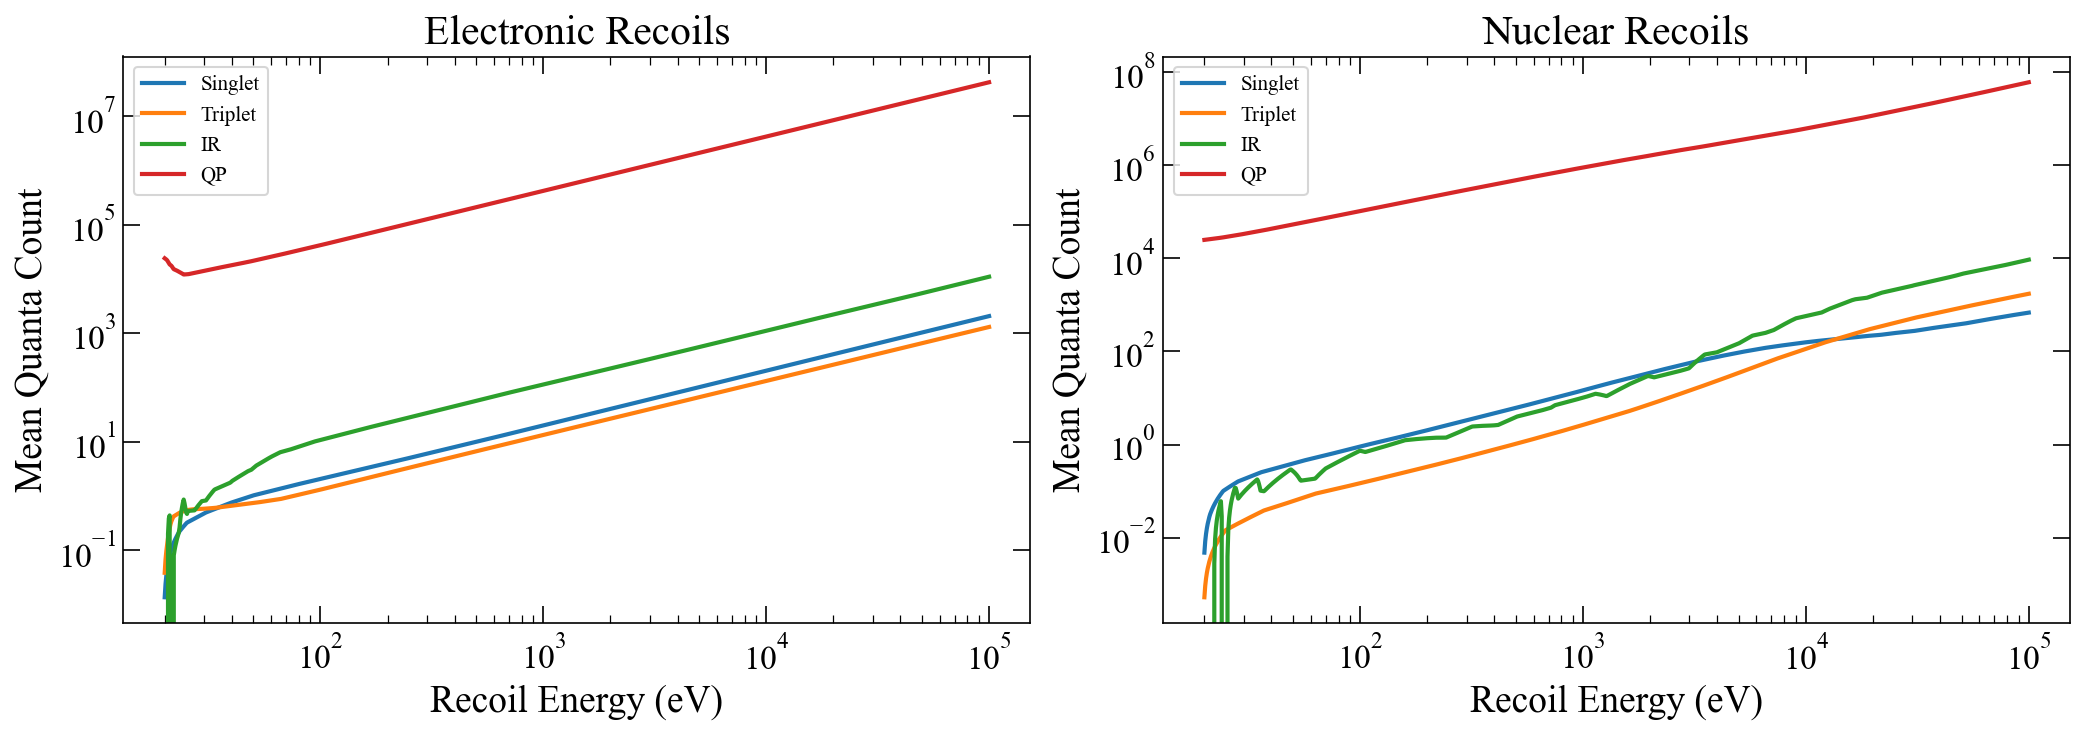

In [40]:
# Mean quanta counts vs. energy
avg_qp_energy = H.Average_QPEnergy(T=2.)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, interaction, title in zip(axes, ['ER', 'NR'],
                                   ['Electronic Recoils', 'Nuclear Recoils']):
    s, t, qp, ir = H.GetEnergyChannelFractions(E_theory, interaction)
    n_singlet = s * E_theory / 15.5
    n_triplet = t * E_theory / 18.0
    n_ir = ir * E_theory / 1.0
    n_qp = qp * E_theory / avg_qp_energy

    ax.plot(E_theory, n_singlet, color=CHANNEL_COLORS[0], label='Singlet')
    ax.plot(E_theory, n_triplet, color=CHANNEL_COLORS[1], label='Triplet')
    ax.plot(E_theory, n_ir, color=CHANNEL_COLORS[2], label='IR')
    ax.plot(E_theory, n_qp, color=CHANNEL_COLORS[3], label='QP')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Recoil Energy (eV)')
    ax.set_ylabel('Mean Quanta Count')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

# Inspect Input Recoil Spectrum

(0.0, 1000.0)

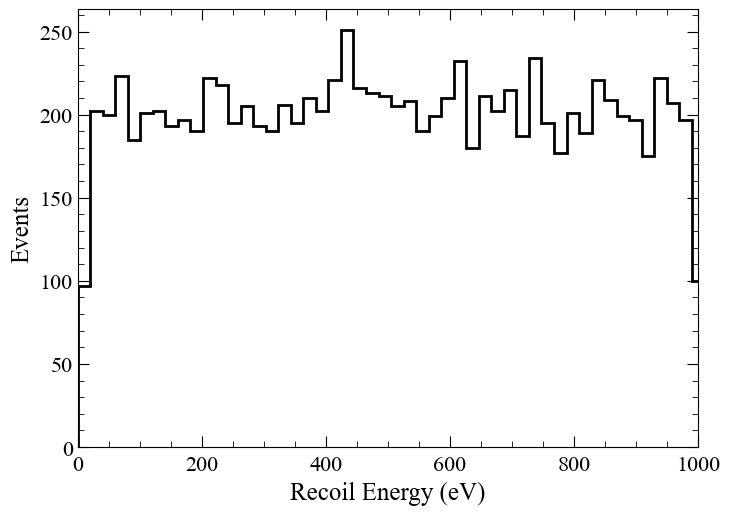

In [42]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(recoil_energies, bins=np.linspace(0,2000,100), lw=2, color='black', histtype='step')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Events')
ax.set_xlim(0,1000)


# Plot Total Detected Energy in Each Signal Channel

Summing over sensors

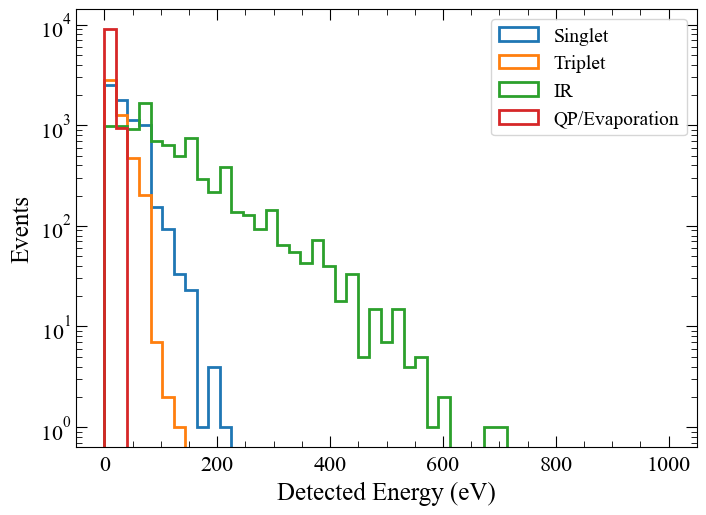

In [ ]:
fig, ax = plt.subplots(1, 1, dpi=100)

bins = np.linspace(0,1000,50)

for ch in range(4):
    vals = detected_energy[:, ch]
    vals = vals[vals > 0]
    ax.hist(vals, bins=bins, lw=2, histtype='step', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch])

ax.set_xlabel('Detected Energy [eV]')
ax.set_ylabel('Events')
ax.set_yscale('log')
ax.legend(frameon=True, loc='upper right',fontsize=14)


## 2D Versions

Text(0, 0.5, 'QPs [eV]')

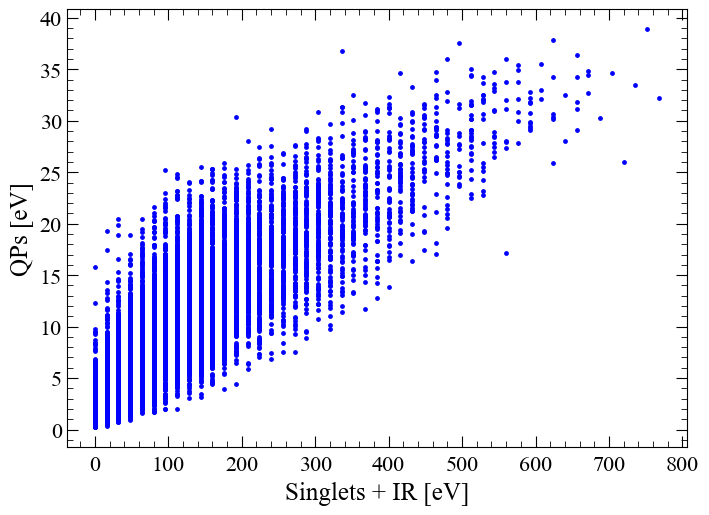

In [52]:
fig, ax = plt.subplots(1,1,dpi=100)

singlet_bins = np.linspace(0,200,20)
qp_bins = np.linspace(0,50,20)

ax.scatter(detected_energy[:,0]+detected_energy[:,2], detected_energy[:,3], s=6, color='blue')

ax.set_xlabel('Singlets + IR [eV]')
ax.set_ylabel('QPs [eV]')

/var/folders/w0/n2ws7mw16vb_37jrv5hgk81h0000gn/T/ipykernel_29045/284440436.py:7: RuntimeWarning: divide by zero encountered in divide
  ax.scatter((detected_energy[:,0]+detected_energy[:,2])/detected_energy[:,2], detected_energy[:,3], s=6, color='blue')
/var/folders/w0/n2ws7mw16vb_37jrv5hgk81h0000gn/T/ipykernel_29045/284440436.py:7: RuntimeWarning: invalid value encountered in divide
  ax.scatter((detected_energy[:,0]+detected_energy[:,2])/detected_energy[:,2], detected_energy[:,3], s=6, color='blue')


Text(0, 0.5, 'QPs [eV]')

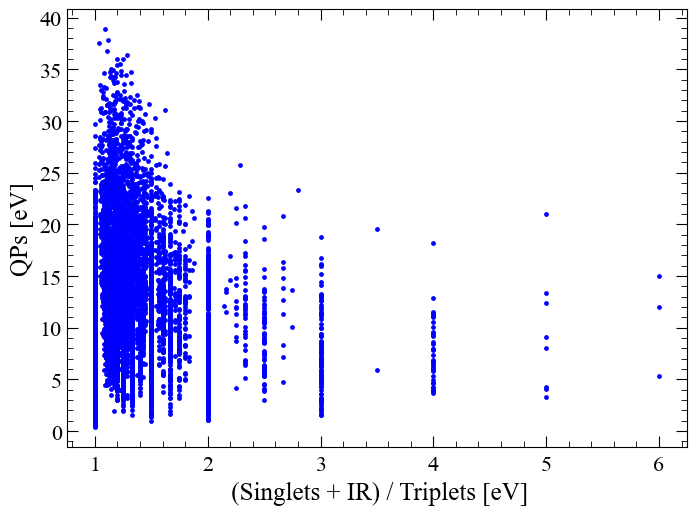

In [53]:
fig, ax = plt.subplots(1,1,dpi=100)

singlet_bins = np.linspace(0,200,20)
qp_bins = np.linspace(0,50,20)
ratio_bins = np.linspace(0,5,20)

ax.scatter((detected_energy[:,0]+detected_energy[:,2])/detected_energy[:,2], detected_energy[:,3], s=6, color='blue')

ax.set_xlabel(' (Singlets + IR) / Triplets [eV]')
ax.set_ylabel('QPs [eV]')

# Fraction of Energy detected per channel

Fraction of generated quanta that are detected, per channel.

In [72]:
def binned_stats(energies, values, n_bins=20):
    """Compute mean and SEM of values in log-spaced energy bins, ignoring NaNs."""
    bins = np.geomspace(energies.min() * 0.9, energies.max() * 1.1, n_bins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])
    means = np.full(n_bins, np.nan)
    sems = np.full(n_bins, np.nan)
    for i in range(n_bins):
        mask = (energies >= bins[i]) & (energies < bins[i+1])
        v = values[mask]
        v = v[~np.isnan(v)]
        if len(v) > 1:
            means[i] = np.mean(v)
            sems[i] = np.std(v) / np.sqrt(len(v))
    return bin_centers, means, sems


/var/folders/w0/n2ws7mw16vb_37jrv5hgk81h0000gn/T/ipykernel_29045/3578369584.py:8: RuntimeWarning: invalid value encountered in divide
  eff = np.where(gen > 0, det / gen, np.nan)


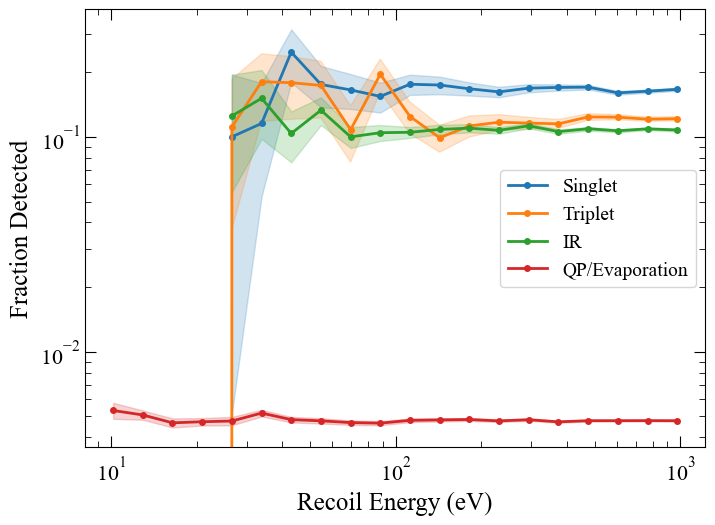

In [73]:
n_bins = 20

fig, ax = plt.subplots(1,1,dpi=100)

for ch in range(4):
    gen = n_quanta_generated[:, ch].astype(float)
    det = detected_count[:, ch].astype(float)
    eff = np.where(gen > 0, det / gen, np.nan)
    bc, mu, sem = binned_stats(recoil_energies, eff, n_bins)
    valid = ~np.isnan(mu)
    ax.plot(bc[valid], mu[valid], 'o-', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch], markersize=4)
    ax.fill_between(bc[valid], (mu - sem)[valid], (mu + sem)[valid], color=CHANNEL_COLORS[ch], alpha=0.2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Fraction Detected')
ax.legend(frameon=True, loc='best', fontsize=14)


## Per-Channel Detected Energy vs. Recoil Energy

Mean detected energy in each channel as a function of recoil energy, with standard-error bands.

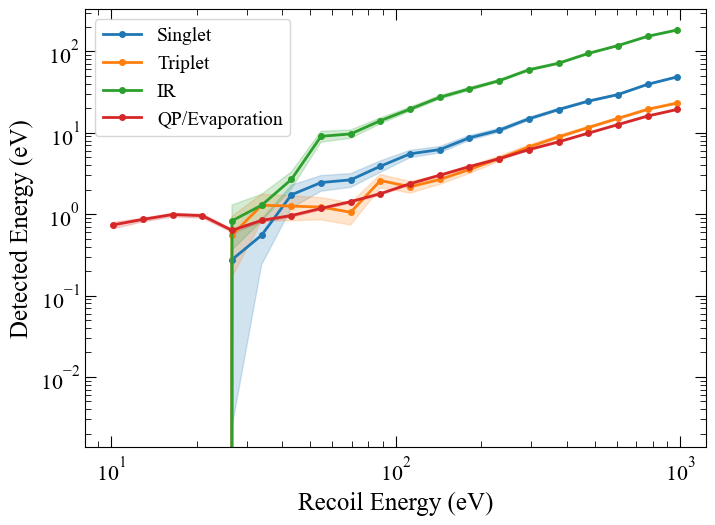

In [74]:
n_bins = 20

fig, ax = plt.subplots(1,1,dpi=100)

for ch in range(4):
    bc, mu, sem = binned_stats(recoil_energies, detected_energy[:, ch], n_bins)
    valid = ~np.isnan(mu)
    ax.plot(bc[valid], mu[valid], 'o-', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch], markersize=4)
    ax.fill_between(bc[valid], (mu - sem)[valid], (mu + sem)[valid], color=CHANNEL_COLORS[ch], alpha=0.2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Detected Energy (eV)')
ax.legend(frameon=True, loc='best', fontsize=14)


# Arrival Time Distributions

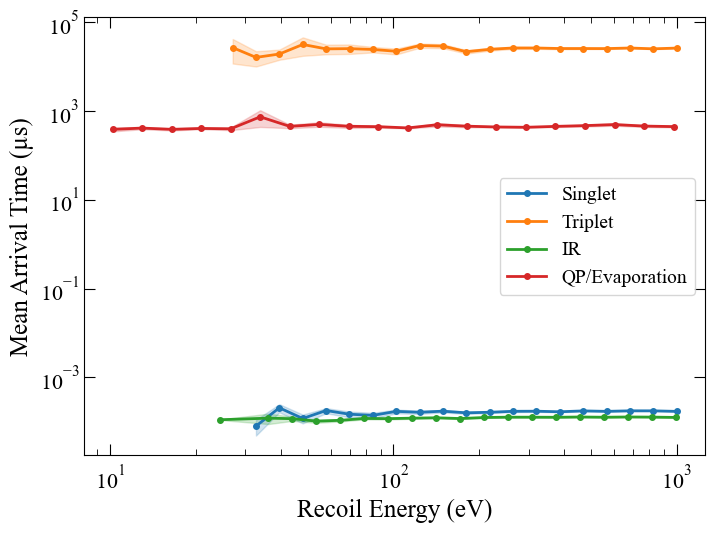

In [76]:
n_bins = 20

fig, ax = plt.subplots(1,1, dpi=100)

for ch in range(4):
    times = mean_arrival_time[:, ch]
    valid_times = ~np.isnan(times)
    if np.sum(valid_times) < 2:
        continue
    bc, mu, sem = binned_stats(recoil_energies[valid_times],
                                times[valid_times], n_bins)
    valid = ~np.isnan(mu)
    ax.plot(bc[valid], mu[valid], 'o-', color=CHANNEL_COLORS[ch], label=CHANNEL_NAMES[ch], markersize=4)
    ax.fill_between(bc[valid], (mu - sem)[valid], (mu + sem)[valid], color=CHANNEL_COLORS[ch], alpha=0.2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Mean Arrival Time (µs)')
ax.legend(frameon=True, loc='best', fontsize=14)



# Arrival Times per event

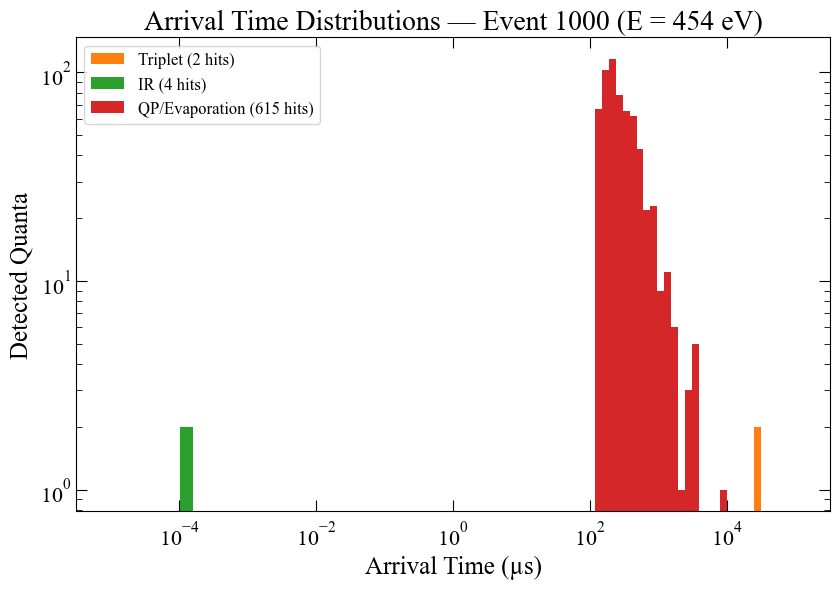

In [127]:
import h5py

H5_FILE = DATA_FILE.replace('.npz', '.h5')

# Set EVENT_INDEX to a specific event, or None to sum over all events
EVENT_INDEX = 1000

channel_keys = ['singlet', 'triplet', 'ir', 'qp']

fig, ax = plt.subplots(1, 1, dpi=100)

with h5py.File(H5_FILE, 'r') as f:
    if EVENT_INDEX is not None:
        event_indices = [EVENT_INDEX]
        title_suffix = f'Event {EVENT_INDEX} (E = {recoil_energies[EVENT_INDEX]:.0f} eV)'
    else:
        event_indices = range(int(f.attrs['n_events']))
        title_suffix = f'All {int(f.attrs["n_events"])} Events'

    for ch, ch_key in enumerate(channel_keys):
        all_times = []
        for evt_i in event_indices:
            evt = f['events'].get(str(evt_i))
            if evt is None:
                continue
            ch_grp = evt.get(ch_key)
            if ch_grp is None:
                continue
            for s_key in ch_grp.keys():
                times = ch_grp[s_key]['arrival_times'][:]
                if len(times) > 0:
                    all_times.append(times)

        if all_times:
            all_times = np.concatenate(all_times)
            all_times = all_times[all_times > 0]
            if len(all_times) > 0:
                bins = np.geomspace(1e-5, 1e5, 100)
                ax.hist(all_times, bins=bins, alpha=1, color=CHANNEL_COLORS[ch],
                        label=f'{CHANNEL_NAMES[ch]} ({len(all_times)} hits)')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Arrival Time (µs)')
ax.set_ylabel('Detected Quanta')
ax.set_title(f'Arrival Time Distributions — {title_suffix}')
ax.legend(frameon=True, fontsize=12)
plt.tight_layout()
plt.show()

# Compare WIMP and Flat ER

In [116]:
ER_FILE = 'Sims/Spectrum_Flat_ER_energyMin_10_energyMax_1000_nEvents_10000_Heraldv1.npz'
WIMP_FILE = 'Sims/Spectrum_Wimp_NR_wimpMass_1000MeV_nEvents_10000_Heraldv1.npz'

er_data = np.load(ER_FILE, allow_pickle=True)
wimp_data = np.load(WIMP_FILE, allow_pickle=True)

print(f'ER:   {len(er_data["recoil_energies"])} events, spectrum={str(er_data["spectrum_mode"])}')
print(f'WIMP: {len(wimp_data["recoil_energies"])} events, mass={float(wimp_data["wimp_mass"])} MeV')

ER:   10000 events, spectrum=flat
WIMP: 10000 events, mass=1000.0 MeV


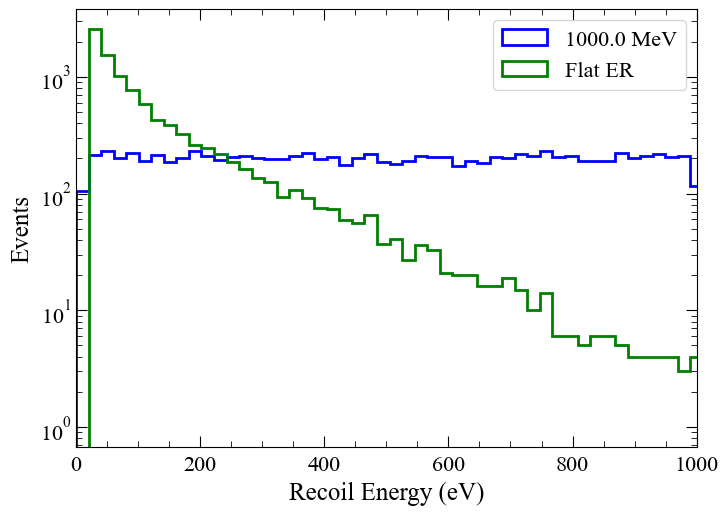

In [117]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(er_data['recoil_energies'], bins=np.linspace(0,2000,100), lw=2, color='blue', histtype='step', label=f'{float(wimp_data["wimp_mass"])} MeV')
ax.hist(wimp_data['recoil_energies'], bins=np.linspace(0,2000,100), lw=2, color='green', histtype='step', label=f'Flat ER')

ax.set_xlabel('Recoil Energy (eV)')
ax.set_ylabel('Events')
ax.set_xlim(0,1000)
ax.set_yscale('log')
ax.legend(frameon=True, fontsize=16)

## Load detected energy in each response channel

Also apply detector smearing

In [109]:
def apply_resolution(energy, sigma, per_sensor=False):
    """
    Apply Gaussian energy resolution smearing to detected signals.

    Parameters
    ----------
    energy : array
        If per_sensor=False: (n_events, 4) total detected energy per channel.  data['detected_energy'] 
        If per_sensor=True:  (n_events, 4, n_sensors) per-sensor detected energy. data['sensor_det_energy']
    sigma : float
        Detector energy resolution (1-sigma) in eV, e.g. 0.500 for 500 meV.
    per_sensor : bool
        If True, apply independent noise to each sensor then sum over sensors.
        If False, apply one noise draw per channel total.

    Returns
    -------
    measured_energy : (n_events, 4) array
        Resolution-smeared detected energy per channel.
    """
    smeared = energy + np.random.normal(0, sigma, size=energy.shape)
    if per_sensor:
        return smeared.sum(axis=2)
    return smeared

In [110]:
er_prompt_photon = er_data['detected_energy'][:, 0] + er_data['detected_energy'][:, 2]
er_delayed_photon = er_data['detected_energy'][:, 1] 
er_qp = er_data['detected_energy'][:, 3]

wimp_prompt_photon = wimp_data['detected_energy'][:, 0] + wimp_data['detected_energy'][:, 2]
wimp_delayed_photon = wimp_data['detected_energy'][:, 1] 
wimp_qp = wimp_data['detected_energy'][:, 3]

# resolution
sigma = 0.5 

er_prompt_photon_smeared = apply_resolution(er_prompt_photon, sigma)
er_delayed_photon_smeared = apply_resolution(er_delayed_photon, sigma)
er_qp_smeared = apply_resolution(er_qp, sigma)

wimp_prompt_photon_smeared = apply_resolution(wimp_prompt_photon, sigma)
wimp_delayed_photon_smeared = apply_resolution(wimp_delayed_photon, sigma)
wimp_qp_smeared = apply_resolution(wimp_qp, sigma)

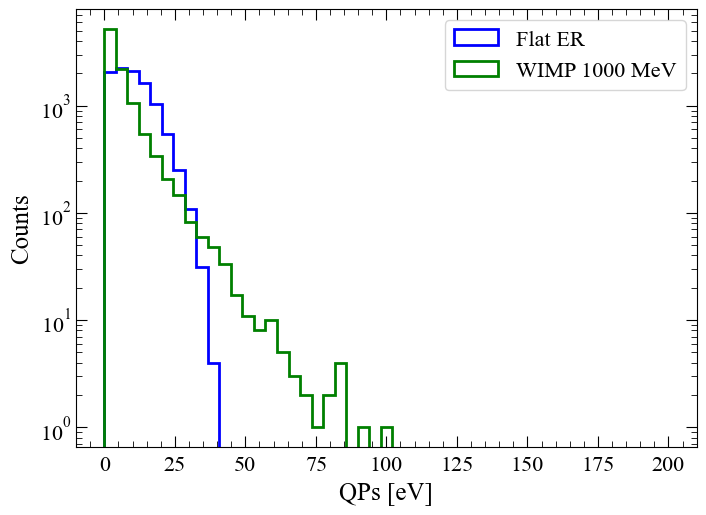

In [111]:
bins = np.linspace(0,200,50)

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(er_qp, bins=bins, lw=2, histtype='step', color='blue', label='Flat ER')
ax.hist(wimp_qp, bins=bins, lw=2, histtype='step', color='green', label=f'WIMP {float(wimp_data["wimp_mass"]):.0f} MeV')

ax.set_yscale('log')
ax.set_xlabel('QPs [eV]')
ax.set_ylabel('Counts')
ax.legend(frameon=True, fontsize=16)

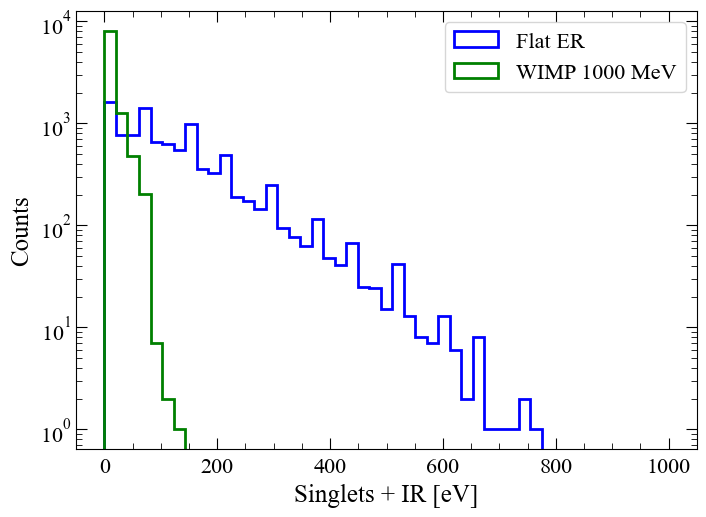

In [112]:
bins = np.linspace(0,1000,50)

fig, ax = plt.subplots(1,1,dpi=100)

ax.hist(er_prompt_photon, bins=bins, lw=2, histtype='step', color='blue', label='Flat ER')
ax.hist(er_delayed_photon, bins=bins, lw=2, histtype='step', color='green', label=f'WIMP {float(wimp_data["wimp_mass"]):.0f} MeV')

ax.set_yscale('log')
ax.set_xlabel('Singlets + IR [eV]')
ax.set_ylabel('Counts')
ax.legend(frameon=True, fontsize=16)

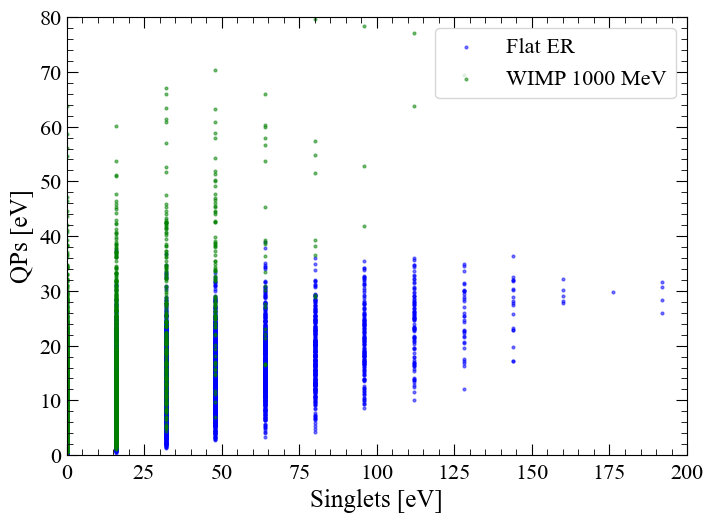

In [114]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.scatter(er_data['detected_energy'][:, 0], er_qp, s=4, alpha=0.5, color='blue', label='Flat ER')
ax.scatter(wimp_data['detected_energy'][:, 0], wimp_qp, s=4, alpha=0.5, color='green', label=f'WIMP {float(wimp_data["wimp_mass"]):.0f} MeV')

ax.set_ylim(0,80)
ax.set_xlim(0,200)
ax.set_xlabel('Singlets [eV]')
ax.set_ylabel('QPs [eV]')
ax.legend(frameon=True, fontsize=16)

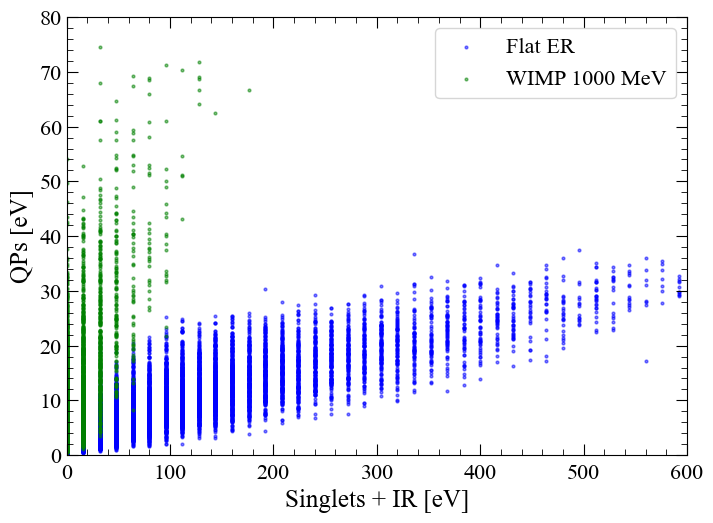

In [104]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.scatter(er_prompt_photon, er_qp, s=4, alpha=0.5, color='blue', label='Flat ER')
ax.scatter(wimp_prompt_photon, wimp_qp, s=4, alpha=0.5, color='green', label=f'WIMP {float(wimp_data["wimp_mass"]):.0f} MeV')

ax.set_ylim(0,80)
ax.set_xlim(0,600)
ax.set_xlabel('Singlets + IR [eV]')
ax.set_ylabel('QPs [eV]')
ax.legend(frameon=True, fontsize=16)

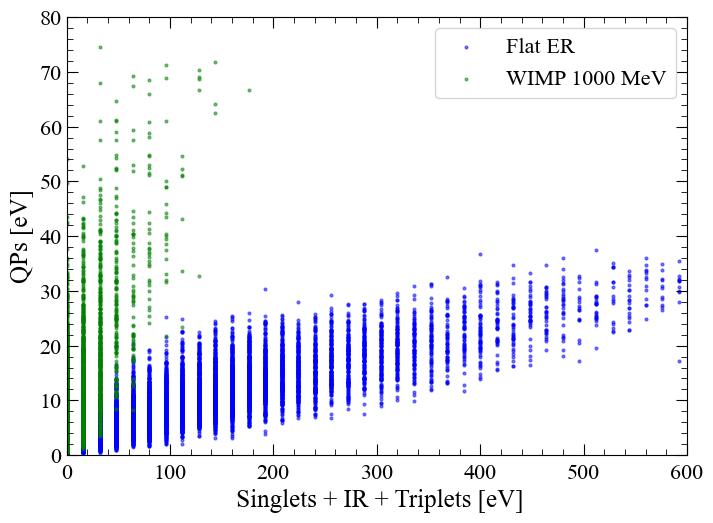

In [100]:
fig, ax = plt.subplots(1,1,dpi=100)

ax.scatter(er_prompt_photon+er_delayed_photon, er_qp, s=4, alpha=0.5, color='blue', label='Flat ER')
ax.scatter(wimp_prompt_photon+wimp_delayed_photon, wimp_qp, s=4, alpha=0.5, color='green', label=f'WIMP {float(wimp_data["wimp_mass"]):.0f} MeV')

ax.set_ylim(0,80)
ax.set_xlim(0,600)
ax.set_xlabel(' Singlets + IR + Triplets [eV]')
ax.set_ylabel('QPs [eV]')
ax.legend(frameon=True, fontsize=16)